In [ ]:
###
    # This code plot the seasonal sensivity of soil temperature simulated by moisture-driven model and CMIP6 models, and also visualizes the influence of supercooled soil water.
    # 1. The moisture-driven sensitivities are calculated from "../Process/10 **.py", and saved in "../Data/Moisture_driven/".
    # 2. The CMIP6 sensitivities are calculated using "05_Ts_sensitivity.py", and saved in "../Data/Ts_seasonal_sensitivity/".
    # 3. Read the sensitivities, then generates: 1) scatter plots comparing moisture-driven sensitivities against CMIP6 sensitivity;
    # 2) Boxplots of moisture-driven sensitivities with and without consideration of supercooled soil water.
    # Output: Figure 4.
###

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

In [2]:
def area_weight_mean(data2D, lat, lon):
    """
    Calculate the area-weighted mean of 2D data, taking into account grid cell areas.
    
    Parameters:
    data2D: ndarray
        Variable for area-weighted averaging, with shape [lat, lon].
    lat: ndarray
        Latitude array, 1D, in degrees.
    lon: ndarray
        Longitude array, 1D, in degrees.
    
    Returns:
    float
        Area-weighted mean of the data.
    """
    # Convert latitude to radians
    rad = np.pi / 180.0
    lat_rad = lat * rad

    # Calculate latitude and longitude resolution
    re = 6371220.0  # Earth radius (in meters)
    dlon = np.abs(lon[1] - lon[0]) * rad  # Longitude resolution (in radians)
    dlat = np.abs(lat[1] - lat[0]) * rad  # Latitude resolution (in radians)

    # Calculate the area of each grid cell
    sin_lat1 = np.sin(lat_rad + dlat / 2)
    sin_lat2 = np.sin(lat_rad - dlat / 2)
    grid_areas = (re ** 2) * dlon * (sin_lat1 - sin_lat2)[:, np.newaxis]  # (lat, lon)

    # Calculate weighted mean
    valid_mask = ~np.isnan(data2D)  # Valid data mask
    weighted_sum = np.nansum(data2D * grid_areas * valid_mask)  # Sum of weighted values
    total_weight = np.nansum(grid_areas * valid_mask)  # Sum of weights

    # If total weight is 0 (all NaN), return NaN
    if total_weight == 0:
        return np.nan

    return weighted_sum / total_weight

In [ ]:
# -----------------------------
# model list
# -----------------------------
models = ["CESM2","CESM2-FV2","CESM2-WACCM",
          "CNRM-CM6-1","CNRM-ESM2-1",
          "GFDL-ESM4","NorESM2-LM",
          "NorESM2-MM","TaiESM1"]
depths = ['1.6m', '2.4m', '3.2m']
CMIP6_amplitude_ratio = pd.DataFrame(index=depths, columns=models)

for j,depth in enumerate([1.6,2.4,3.2]):

    # Load the permafrost probability data for the given depth
    q = xr.open_dataset('../Data/probability_lt_threshold_'+str(int(depth*100))+'.nc')
    per_extent = q['probability_lt_threshold'][:,:360] # longitude limited to 0-180° Eurasian continent portion
    for i in range(len(models)):
        modelname = models[i]
        Ts_file = '../Data/Ts_seasonal_sensitivity/Simulated_grid_sensitivity/'+str(int(depth*100))+'/' + modelname + '_tsl_seasonalcycle_avg.nc'
        g = xr.open_dataset(Ts_file)
        tsl_seasonalcycle_avg2 = g['tsl_seasonalcycle_avg']
        lat = g["lat"]
        lon = g["lon"]

        # Seasonal-scale soil temperature sensitivity masked by per_extent probability
        tsl_seasonalcycle_avg2 = xr.where(per_extent==0, np.nan, tsl_seasonalcycle_avg2)
        tsl_seasonalcycle_avg2 = xr.where(per_extent==1, np.nan, tsl_seasonalcycle_avg2)
        CMIP6_amplitude_ratio[modelname][depths[j]] = area_weight_mean(tsl_seasonalcycle_avg2, lat.data, lon.data)
    
CMIP6_amplitude_ratio

,CESM2,CESM2-FV2,CESM2-WACCM,CNRM-CM6-1,CNRM-ESM2-1,GFDL-ESM4,NorESM2-LM,NorESM2-MM,TaiESM1
1.6m,0.502997,0.519459,0.514431,0.389581,0.37453,0.35899,0.484341,0.527313,0.383332
2.4m,0.386471,0.393438,0.393872,0.254832,0.236882,0.258903,0.367329,0.402671,0.280637
3.2m,0.302768,0.305014,0.308403,0.178587,0.164538,0.195684,0.284069,0.314444,0.224049


In [4]:
amplitude_ratio_offsup = pd.read_csv("../Data/Moisture_driven/Ts_seasonal_sensitivity_offsup.csv")
amplitude_ratio_offsup = amplitude_ratio_offsup.iloc[:,1:]
amplitude_ratio_onsup = pd.read_csv("../Data/Moisture_driven/Ts_seasonal_sensitivity_onsup.csv")
amplitude_ratio_onsup = amplitude_ratio_onsup.iloc[:,1:]
amplitude_ratio_onsup

,CESM2,CESM2-FV2,CESM2-WACCM,CNRM-CM6-1,CNRM-ESM2-1,GFDL-ESM4,NorESM2-LM,NorESM2-MM,TaiESM1
0,0.457996,0.479147,0.475168,0.401611,0.377545,0.377075,0.458004,0.487590,0.362700
1,0.333228,0.341089,0.344214,0.270865,0.249996,0.266751,0.303509,0.352347,0.248445
2,0.246479,0.250641,0.255622,0.191595,0.173851,0.199129,0.203777,0.262174,0.175319


mean_on 0.43075957635691653
mean_off 0.3934470991937448
-8.662019189157975 %
mean_on 0.3011603399735956
mean_off 0.2764580132828312
-8.202383717899302 %
mean_on 0.21762084276947696
mean_off 0.20222502416218205
-7.074606646755574 %


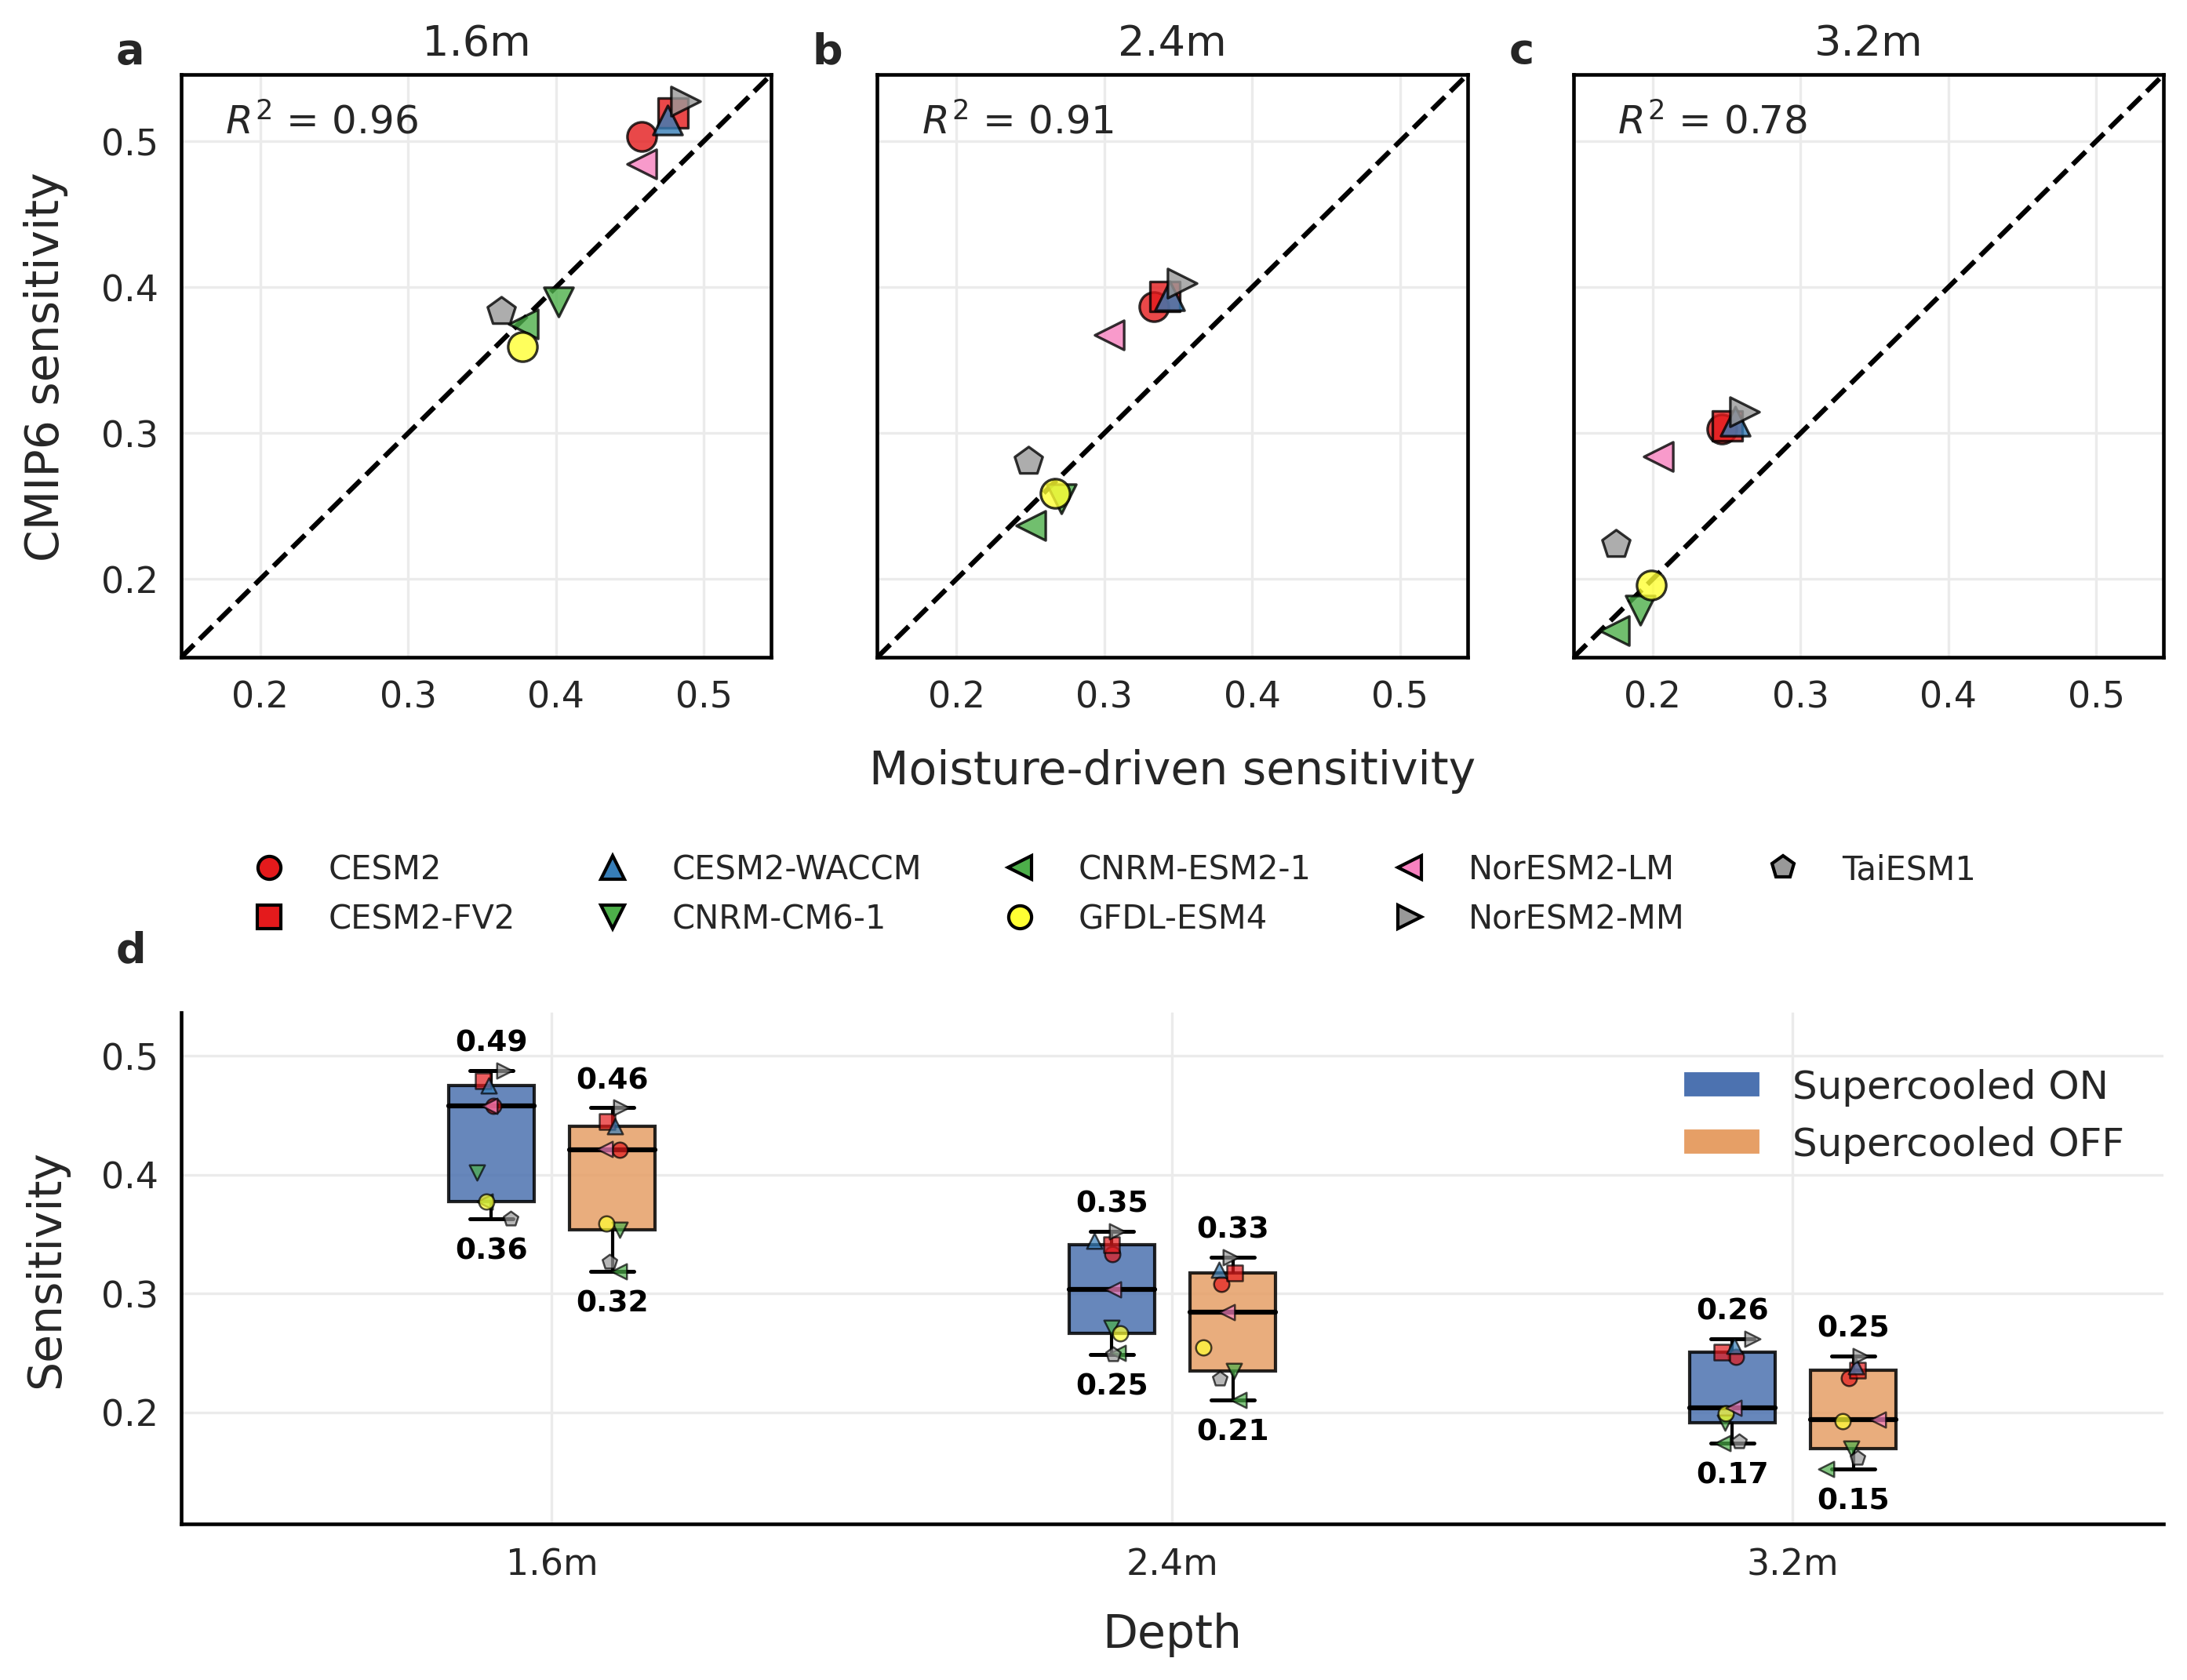

In [ ]:
# -----------------------------
# style
# -----------------------------
plt.rcParams.update({
    "font.size":10,
    "axes.labelsize":12,
    "axes.titlesize":13,
    "axes.linewidth":1.1,
    "xtick.labelsize":11,
    "ytick.labelsize":11
})

models_all = ["CESM2", "CESM2-FV2", "CESM2-WACCM", "CNRM-CM6-1-HR", "CNRM-CM6-1", "CNRM-ESM2-1",
             "E3SM-1-1", "FGOALS-f3-L", "FGOALS-g3", "GFDL-CM4", "GFDL-ESM4", "MIROC6",
             "MIROC-ES2L", "MPI-ESM1-2-HR", "MPI-ESM1-2-LR", "NorESM2-LM", "NorESM2-MM", "TaiESM1"]

# Markers and colors for all models
markers_all = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']
colors_all = plt.cm.Set1(np.linspace(0, 1, len(models_all)))

# Create a mapping dictionary from model to fixed marker and color
model_style = {}
for i, model in enumerate(models_all):
    model_style[model] = {
        'marker': markers_all[i % len(markers_all)],
        'color': colors_all[i]
    }

# Assign colors and markers to current models based on the mapping dictionary
markers = [model_style[model]['marker'] for model in models]
colors = [model_style[model]['color'] for model in models]

# =============================
# create plot
# =============================
fig = plt.figure(figsize=(9.36,8), dpi=300)
gs = gridspec.GridSpec(
    2, 3,
    height_ratios=[1.39, 1.22],
    hspace=0.65,
    wspace=0.18,
    left=0.08,
    right=0.98
)

# =============================
# ===== upper scatter =====
# =============================
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

# reshape data
data_list=[]
for i,depth in enumerate(depths):
    for model in models:
        data_list.append({
            "Depth":depth,
            "Model":model,
            "Moisture":amplitude_ratio_onsup.loc[i,model],
            "CMIP6":CMIP6_amplitude_ratio.loc[depth,model]
        })

plot_data=pd.DataFrame(data_list)

x_all=plot_data["Moisture"].values
y_all=plot_data["CMIP6"].values
data_min=min(x_all.min(),y_all.min())
data_max=max(x_all.max(),y_all.max())
margin=(data_max-data_min)*0.05
plot_range=[data_min-margin,data_max+margin]

for idx,(ax,depth) in enumerate(zip(axes,depths)):

    depth_data=plot_data[plot_data["Depth"]==depth]

    for i,(_,row) in enumerate(depth_data.iterrows()):
        model=row["Model"]


        color=colors[i]
        lw=0.8

        ax.scatter(
            row["Moisture"],
            row["CMIP6"],
            marker=markers[i],
            s=80,
            color=color,
            edgecolor="black",
            linewidth=lw,
            alpha=0.8,
            label=model if idx==0 else "",
            zorder=3
        )

    # --- Set unified y-axis ticks with 0.1 spacing ---
    ticks = np.arange(
        np.floor(plot_range[0]*10)/10,
        np.ceil(plot_range[1]*10)/10 + 0.1,
        0.1
    )
    ax.set_yticks(ticks)
    ax.set_xticks(ticks)

    # --- Keep y-axis only for subplot a ---
    if idx != 0:
        ax.set_yticklabels([]) 
        ax.set_ylabel("")          # remove label

    # 1:1 line
    ax.plot(plot_range, plot_range, 'k--', linewidth=1.5)

    # R²
    x=depth_data["Moisture"].values
    y=depth_data["CMIP6"].values
    r,_=stats.pearsonr(x,y)
    ax.text(0.075,0.9,f"$R^2$ = {r**2:.2f}",transform=ax.transAxes,fontsize=12)

    # panel label
    ax.text(-0.11,1.02,f"{chr(97+idx)}",
            transform=ax.transAxes,fontsize=13,fontweight="bold")

    ax.set_title(depth)
    ax.set_xlim(plot_range)
    ax.set_ylim(plot_range)

    if idx==0:
        ax.set_ylabel("CMIP6 sensitivity",labelpad=10,fontsize=14)
    if idx==1:
        ax.set_xlabel("Moisture-driven sensitivity",labelpad=10,fontsize=14)

# legend（scatter）
legend_elements=[]
for i,model in enumerate(models):
    color = colors[i]
    legend_elements.append(
        Line2D([0],[0],marker=markers[i],linestyle="None",
               markerfacecolor=color,markeredgecolor="black",
               markersize=7,label=model)
    )

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5,0.482),
    ncol=5,
    frameon=False
)

# =============================
# ===== bottom boxplot =====
# =============================
ax = fig.add_subplot(gs[1, :]) 

models = amplitude_ratio_onsup.columns

box_colors = ['#4C72B0', '#E69F66']

positions = []
data = []
colors_box = []

width = 0.195
base_positions = np.arange(len(depths))

for i, depth in enumerate(depths):
    onsup = amplitude_ratio_onsup.loc[i,:].dropna().values
    offsup = amplitude_ratio_offsup.loc[i,:].dropna().values

    data.extend([onsup, offsup])

    positions.extend([
        base_positions[i]-width/2,
        base_positions[i]+width/2
    ])

    colors_box.extend(box_colors)

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.138,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(
        color='black',
        linewidth=1.5
    ),
    capprops=dict(
        linewidth=1.2, 
        color='black'
    )
)

for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

# scatter overlay
k = 0
for j, depth in enumerate(depths):
    for dataset in [amplitude_ratio_onsup, amplitude_ratio_offsup]:
        pos = positions[k]

        for i, model in enumerate(models):
            value = dataset.loc[j, model]
            if np.isnan(value):
                continue

            x = np.random.normal(pos, 0.015)

            color = colors[i]
            lw = 0.6

            ax.scatter(x, value, marker=markers[i], s=22,
                       color=color, edgecolor="black",alpha=0.7,
                       linewidth=lw, zorder=3)
        k += 1

# =============================
# Mark mean values and variance reduction
# =============================
for i, depth in enumerate(depths):
    # Calculate means
    mean_on = np.mean(amplitude_ratio_onsup.loc[i, :].dropna())
    mean_off = np.mean(amplitude_ratio_offsup.loc[i, :].dropna())
    print('mean_on',mean_on)
    print('mean_off',mean_off)
    print((mean_off-mean_on)/mean_on*100,'%')

    onsup = amplitude_ratio_onsup.loc[i, :].dropna().values
    offsup = amplitude_ratio_offsup.loc[i, :].dropna().values
    
    max_on = np.max(onsup)
    min_on = np.min(onsup)
    range_on = max_on - min_on
    
    max_off = np.max(offsup)
    min_off = np.min(offsup)
    range_off = max_off - min_off

    # Determine y position for text (above the highest data point)
    if i==0:
        y = min(
            amplitude_ratio_onsup.loc[i,:].max(),
            amplitude_ratio_offsup.loc[i,:].max()
        ) - 0.17
    elif i==1:
        y = min(
            amplitude_ratio_onsup.loc[i,:].max(),
            amplitude_ratio_offsup.loc[i,:].max()
        ) + 0.15
    else:
        y = max(
        amplitude_ratio_onsup.loc[i,:].max(),
        amplitude_ratio_offsup.loc[i,:].max()
    ) + 0.1

    # Mark max/min values on each bar
    # ON (left bar)
    ax.text(base_positions[i]- width/2, max_on+0.011, 
            f'{max_on:.2f}', 
            ha='center', va='bottom', fontsize=9, 
            color='black', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.068', alpha=0.7, edgecolor='none', facecolor='none'))
    ax.text(base_positions[i]- width/2, min_on-0.015, 
            f'{min_on:.2f}', 
            ha='center', va='top', fontsize=9, 
            color='black', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.068', alpha=0.7, edgecolor='none', facecolor='none'))

    # OFF (right bar)
    ax.text(base_positions[i] + width/2, max_off+0.011, 
            f'{max_off:.2f}', 
            ha='center', va='bottom', fontsize=9, 
            color='black', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.068', alpha=0.8, edgecolor='none', facecolor='none'))
    ax.text(base_positions[i] + width/2, min_off-0.015, 
            f'{min_off:.2f}', 
            ha='center', va='top', fontsize=9, 
            color='black', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.068', alpha=0.8, edgecolor='none', facecolor='none'))

# panel label
ax.text(-0.033, 1.1, f"{chr(97+3)}",
        transform=ax.transAxes,
        fontsize=13, fontweight="bold")

# axis
ax.set_xticks(base_positions)
ax.set_xticklabels(depths)
ax.set_ylabel('Sensitivity', labelpad=10, fontsize=14)
ax.set_xlabel('Depth', labelpad=9, fontsize=14)

ax.set_ylim(bottom=0.106, top=0.536)

ax.legend(
    handles=[
        Patch(facecolor=colors_box[0], label='Supercooled ON'),  
        Patch(facecolor=colors_box[1], label='Supercooled OFF') 
    ],
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(0.998, 0.96),
    fontsize = 12
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [ ]:
fig.savefig("../Figures/Figure4.png", bbox_inches='tight',dpi=300)